# Triple Products

Cycle-test circuits for measuring the real parts of triple products `Re tr(σ_i σ_j σ_k)` for WH orbit states in `cirq_sic`.

In [1]:
from math import comb
import numpy as np
import cirq

from cirq_sic import *

In [20]:
d = 8
phi = load_sic_fiducial(d)

task = CharacterizeWHTripleProductsTask(
    dataset_id='notebook',
    processor_id='willow_pink',
    run_type='clean',
    qubits=get_triple_product_qubits(d),
    n_shots=500,
    optimizer='cirq',
    d=d,
    fiducial=phi,
    fiducial_description='numerical_sic',
)

#tensor_exact = exactify(task)['T']
orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
tensor_exact = np.array([
    [[np.trace(rho_i @ rho_j @ rho_k).real for rho_k in orbit_projectors]
     for rho_j in orbit_projectors]
    for rho_i in orbit_projectors
])

print('Unique circuits:', len(task.make_circuits()), 'of', comb(d**2 + 2, 3))
print('Tensor shape:', tensor_exact.shape)
print('Symmetric:', np.allclose(tensor_exact, np.transpose(tensor_exact, (1, 0, 2))))
#print('Matches NumPy:', np.allclose(tensor_exact, tensor_numpy))

base_dir = 'tmp_triple_products'
run_sky_ground_task(task, base_dir=base_dir)
results = load_results(task, base_dir=base_dir)
tensor_empirical = np.array(results["processed_data"]["T"])

KeyboardInterrupt: 

In [16]:
circuits = load_circuits(task, base_dir=base_dir)

In [18]:
circuits[0]

(4, 2): ───PhX(-0.678)^0.306───@───PhX(0.404)^0.392───@───PhXZ(a=-0.596,x=0.332,z=0.0964)───@────────────PhX(1)^0.5──────@───────────────PhX(-2.22e-16)^0.5───@────────────────────S^-1────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────PhXZ(a=0.5,x=0.5,z=0)───@───PhXZ(a=-0.5,x=0.5,z=0.25)──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────PhXZ(a=0.5,x=0.5,z=0)───@───PhXZ(a=-0.5,x=0.5,z=0)────────────────────────────────────────────────────────────────────────────@───PhXZ(a=-0.25,x=0.5,z=0.75)───@───PhXZ(a=-0.5,x=0.5,z=0)───@───PhXZ(a=-0.5,x=0.5,z=-1)──────@───PhXZ(a=-0.5,x=0.5,z=0)───@───PhXZ(a=-0.5,x=0.5,z=0.5)─────@───PhXZ(a=-0.5,x=0.5,z=0)──────@───PhXZ(a=-1,x=0.5,z=-1)──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                               │                      │                                     │                            │                                    │                                                                                                                                                                                                                                                                                                                                                                                                                                │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              │                                                                                                     │                                │                            │                                │                            │                                │                               │
(4, 3): ───PhX(-0.412)^0.368───@──────────────────────@───PhXZ(a=0.0519,x=0.789,z=-0.39)────┼────────────────────────────┼────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼───PhXZ(a=0,x=0.5,z=0)─────────@───PhX(1)^0.5──────@───PhX(-2.22e-16)^0.5───@───

In [19]:
get_gate_counts(circuits[0])

Counter({'PhasedXZGate': 132,
         'CZPowGate': 69,
         'PhasedXPowGate': 38,
         'ZPowGate': 2})

In [14]:
def _prepare_validity_map(T):
    n = T.shape[0]
    d = int(np.sqrt(n))
    P = np.sum(T, axis=0) / d**2
    Phi = np.linalg.pinv(P)
    return Phi


def _filter_valid_probabilities(probabilities, T, Phi=None):
    probabilities = np.asarray(probabilities, dtype=float)
    if Phi is None:
        Phi = _prepare_validity_map(T)
    L = np.einsum("ijk,kl->lij", T, Phi @ probabilities.T)
    valid = np.all(np.linalg.eigvals(L) >= 0, axis=1)
    return probabilities[valid]


def simplex_center(n_outcomes):
    return np.ones(n_outcomes) / n_outcomes


def simplex_projection_basis(n_outcomes):
    if n_outcomes < 2:
        raise ValueError('Need at least two outcomes to define a simplex hyperplane.')

    raw_basis = np.zeros((n_outcomes, n_outcomes - 1), dtype=float)
    raw_basis[:-1, :] = np.eye(n_outcomes - 1)
    raw_basis[-1, :] = -1
    q, _ = np.linalg.qr(raw_basis)
    return q[:, : n_outcomes - 1]


def project_probability_vectors(probabilities, basis=None):
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.ndim != 2:
        raise ValueError('Expected shape (n_points, n_outcomes).')
    n_outcomes = probabilities.shape[1]
    center = simplex_center(n_outcomes)
    if basis is None:
        basis = simplex_projection_basis(n_outcomes)
    return (probabilities - center) @ basis


def _dedupe_rows(points, decimals=10):
    points = np.asarray(points, dtype=float)
    if len(points) == 0:
        width = points.shape[-1] if points.ndim > 1 else 0
        return points.reshape(0, width)
    _, idx = np.unique(np.round(points, decimals=decimals), axis=0, return_index=True)
    return points[np.sort(idx)]


def sample_valid_probabilities(N, T, *, seed=None):
    n = T.shape[0]
    rng = np.random.default_rng(seed)
    p = rng.dirichlet(np.ones(n), size=N)
    Phi = _prepare_validity_map(T)
    return _filter_valid_probabilities(p, T, Phi=Phi)


def _sample_simplex_shell(n_outcomes, n_samples, inner_radius, outer_radius, *, seed=None, oversample_factor=3):
    if outer_radius <= inner_radius:
        raise ValueError('outer_radius must be larger than inner_radius.')

    rng = np.random.default_rng(seed)
    center = simplex_center(n_outcomes)
    basis = simplex_projection_basis(n_outcomes)
    intrinsic_dim = basis.shape[1]

    collected = []
    needed = n_samples
    outer_power = outer_radius ** intrinsic_dim
    inner_power = inner_radius ** intrinsic_dim

    while needed > 0:
        batch_size = max(oversample_factor * needed, 128)
        directions = rng.normal(size=(batch_size, intrinsic_dim))
        norms = np.linalg.norm(directions, axis=1, keepdims=True)
        directions = directions / norms

        u = rng.random(batch_size)
        radii = (inner_power + u * (outer_power - inner_power)) ** (1 / intrinsic_dim)
        intrinsic_points = directions * radii[:, None]
        probabilities = center + intrinsic_points @ basis.T
        mask = np.all(probabilities >= 0, axis=1)
        accepted = probabilities[mask]
        if len(accepted) == 0 and batch_size > 20 * n_samples:
            break
        if len(accepted) > 0:
            collected.append(accepted[:needed])
            needed -= len(accepted[:needed])

    if not collected:
        return np.empty((0, n_outcomes))
    return np.vstack(collected)


def collect_valid_probabilities_center_outward(
    target_count,
    T,
    *,
    shell_batch_size=4000,
    shell_radii=None,
    max_consecutive_sparse_shells=2,
    min_valid_per_shell=5,
    oversample_factor=3,
    seed=None,
    min_count=2,
):
    n_outcomes = T.shape[0]
    Phi = _prepare_validity_map(T)
    rng = np.random.default_rng(seed)

    if shell_radii is None:
        max_radius = np.sqrt((n_outcomes - 1) / n_outcomes)
        shell_radii = np.linspace(0.0, 0.9 * max_radius, 13)

    collected = []
    consecutive_sparse_shells = 0

    for inner_radius, outer_radius in zip(shell_radii[:-1], shell_radii[1:]):
        shell_seed = int(rng.integers(0, 2**32 - 1))
        candidates = _sample_simplex_shell(
            n_outcomes,
            shell_batch_size,
            inner_radius,
            outer_radius,
            seed=shell_seed,
            oversample_factor=oversample_factor,
        )
        valid_shell = _filter_valid_probabilities(candidates, T, Phi=Phi) if len(candidates) else np.empty((0, n_outcomes))

        print(
            f'shell [{inner_radius:.4f}, {outer_radius:.4f}] -> '
            f'{len(valid_shell)} valid / {len(candidates)} sampled'
        )

        if len(valid_shell) > 0:
            collected.append(valid_shell)

        total = sum(len(chunk) for chunk in collected)
        if total >= target_count:
            break

        if len(valid_shell) < min_valid_per_shell:
            consecutive_sparse_shells += 1
        else:
            consecutive_sparse_shells = 0

        if consecutive_sparse_shells >= max_consecutive_sparse_shells:
            break

    if not collected or sum(len(chunk) for chunk in collected) < min_count:
        raise ValueError(
            'Too few valid probability vectors were found with center-out shell sampling. '
            'Increase shell_batch_size or add more/larger shells.'
        )

    valid_p = _dedupe_rows(np.vstack(collected))
    if len(valid_p) > target_count:
        idx = rng.choice(len(valid_p), size=target_count, replace=False)
        valid_p = valid_p[idx]
    return valid_p

## Projection Snapshots

In [18]:
from itertools import combinations
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull


PROJECTION_CONFIG = {
    'cache_path': Path('triple_products_fast_d%d_cache.npz' % d),
    'refresh_cache': True,
    'target_count_exact': 1500,
    'target_count_empirical': 1500,
    'shell_batch_size_exact': 12000,
    'shell_batch_size_empirical': 12000,
    'shell_radii': None,
    'max_consecutive_sparse_shells': 5,
    'min_valid_per_shell': 8,
    'oversample_factor': 4,
    'seed_exact': 1,
    'seed_empirical': 0,
    'plot_max_points_per_set': 600,
    'max_2d': 4,
    'max_3d': 4,
}


def collect_projection_points(config):
    cache_path = config['cache_path']
    if cache_path.exists() and not config['refresh_cache']:
        cache = np.load(cache_path)
        valid_p = cache['valid_p']
        valid_p_exact = cache['valid_p_exact']
        print(f'Loaded cached valid points from {cache_path}')
        return valid_p, valid_p_exact

    print('Sampling valid points for tensor_exact from the simplex center outward...')
    valid_p_exact = collect_valid_probabilities_center_outward(
        config['target_count_exact'],
        tensor_exact,
        shell_batch_size=config['shell_batch_size_exact'],
        shell_radii=config['shell_radii'],
        max_consecutive_sparse_shells=config['max_consecutive_sparse_shells'],
        min_valid_per_shell=config['min_valid_per_shell'],
        oversample_factor=config['oversample_factor'],
        seed=config['seed_exact'],
    )

    print('Sampling valid points for tensor_empirical from the simplex center outward...')
    valid_p = collect_valid_probabilities_center_outward(
        config['target_count_empirical'],
        tensor_empirical,
        shell_batch_size=config['shell_batch_size_empirical'],
        shell_radii=config['shell_radii'],
        max_consecutive_sparse_shells=config['max_consecutive_sparse_shells'],
        min_valid_per_shell=config['min_valid_per_shell'],
        oversample_factor=config['oversample_factor'],
        seed=config['seed_empirical'],
    )

    np.savez(cache_path, valid_p=valid_p, valid_p_exact=valid_p_exact)
    print(f'Saved valid points to {cache_path}')
    return valid_p, valid_p_exact


def fit_shared_pca_basis(point_sets):
    stacked = np.vstack(point_sets)
    centered = stacked - stacked.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    return vh.T


def default_projection_specs(shared_basis, max_2d=4, max_3d=4):
    n_axes = shared_basis.shape[1]
    pair_candidates = list(combinations(range(min(n_axes, 5)), 2))
    triple_candidates = list(combinations(range(min(n_axes, 5)), 3))

    specs = []
    for axes in pair_candidates[:max_2d]:
        specs.append({'dim': 2, 'axes': axes, 'title': f'PC{axes[0]+1} vs PC{axes[1]+1}'})
    for axes in triple_candidates[:max_3d]:
        specs.append({'dim': 3, 'axes': axes, 'title': f'PC{axes[0]+1}, PC{axes[1]+1}, PC{axes[2]+1}'})
    return specs


def project_with_shared_basis(points, shared_basis, axes):
    return points @ shared_basis[:, axes]


def _subsample_points(points, max_points, seed=0):
    points = _dedupe_rows(points)
    if len(points) <= max_points:
        return points
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(points), size=max_points, replace=False)
    return points[idx]


def _set_equal_2d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_aspect('equal')


def _set_equal_3d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def _plot_projected_hulls_2d(ax, point_sets, colors, alphas):
    shown = []
    for points, color, alpha in zip(point_sets, colors, alphas):
        shown.append(points)
        ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.10, color=color)
        if len(points) >= 3:
            hull = ConvexHull(points, qhull_options='QJ')
            polygon = points[hull.vertices]
            ax.fill(polygon[:, 0], polygon[:, 1], color=color, alpha=alpha, edgecolor=color, linewidth=0.8)
            closed = np.vstack([polygon, polygon[0]])
            ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=0.8)
    _set_equal_2d_axes(ax, np.vstack(shown))


def _plot_projected_hulls_3d(ax, point_sets, colors, alphas):
    shown = []
    for points, color, alpha in zip(point_sets, colors, alphas):
        shown.append(points)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=8, alpha=0.10, color=color)
        if len(points) >= 4:
            hull = ConvexHull(points, qhull_options='QJ')
            faces = [points[simplex] for simplex in hull.simplices]
            poly = Poly3DCollection(faces, facecolor=color, edgecolor=color, linewidth=0.2, alpha=alpha)
            ax.add_collection3d(poly)
    _set_equal_3d_axes(ax, np.vstack(shown))


def plot_projection_snapshots(
    valid_p,
    valid_p_exact,
    *,
    max_points_per_set=600,
    max_2d=4,
    max_3d=4,
    colors=('C0', 'C2'),
    labels=('experiment', 'theory'),
    alphas=(0.30, 0.14),
    figsize_scale=4.8,
    seed=0,
    filename=None,
):
    intrinsic_valid = project_probability_vectors(valid_p)
    intrinsic_exact = project_probability_vectors(valid_p_exact)

    shared_basis = fit_shared_pca_basis([intrinsic_valid, intrinsic_exact])
    specs = default_projection_specs(shared_basis, max_2d=max_2d, max_3d=max_3d)

    n_panels = len(specs)
    ncols = 2
    nrows = ceil(n_panels / ncols)
    fig = plt.figure(figsize=(figsize_scale * ncols, figsize_scale * nrows))
    gs = GridSpec(nrows, ncols, figure=fig)

    for i, spec in enumerate(specs):
        row, col = divmod(i, ncols)
        dim = spec['dim']
        axes = tuple(spec['axes'])
        if dim == 3:
            ax = fig.add_subplot(gs[row, col], projection='3d')
        else:
            ax = fig.add_subplot(gs[row, col])

        proj_valid = _subsample_points(project_with_shared_basis(intrinsic_valid, shared_basis, axes), max_points_per_set, seed=seed)
        proj_exact = _subsample_points(project_with_shared_basis(intrinsic_exact, shared_basis, axes), max_points_per_set, seed=seed + 1)

        if dim == 2:
            _plot_projected_hulls_2d(ax, [proj_valid, proj_exact], colors, alphas)
            ax.set_xlabel(f'PC{axes[0]+1}')
            ax.set_ylabel(f'PC{axes[1]+1}')
        else:
            _plot_projected_hulls_3d(ax, [proj_valid, proj_exact], colors, alphas)
            ax.set_xlabel(f'PC{axes[0]+1}')
            ax.set_ylabel(f'PC{axes[1]+1}')
            ax.set_zlabel(f'PC{axes[2]+1}')
        ax.set_title(spec['title'])

    handles = [Patch(facecolor=c, edgecolor=c, alpha=a, label=l) for c, a, l in zip(colors, alphas, labels)]
    fig.legend(handles=handles, loc='upper right')
    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename, bbox_inches='tight')
        print(f'Saved figure to {filename}')
    plt.show()


valid_p, valid_p_exact = collect_projection_points(PROJECTION_CONFIG)
print('valid_p shape:', valid_p.shape)
print('valid_p_exact shape:', valid_p_exact.shape)

Sampling valid points for tensor_exact from the simplex center outward...
shell [0.0000, 0.0726] -> 11700 valid / 12000 sampled
Sampling valid points for tensor_empirical from the simplex center outward...
shell [0.0000, 0.0726] -> 4875 valid / 12000 sampled
Saved valid points to triple_products_fast_d4_cache.npz
valid_p shape: (1500, 16)
valid_p_exact shape: (1500, 16)


Saved figure to triples_d4.pdf


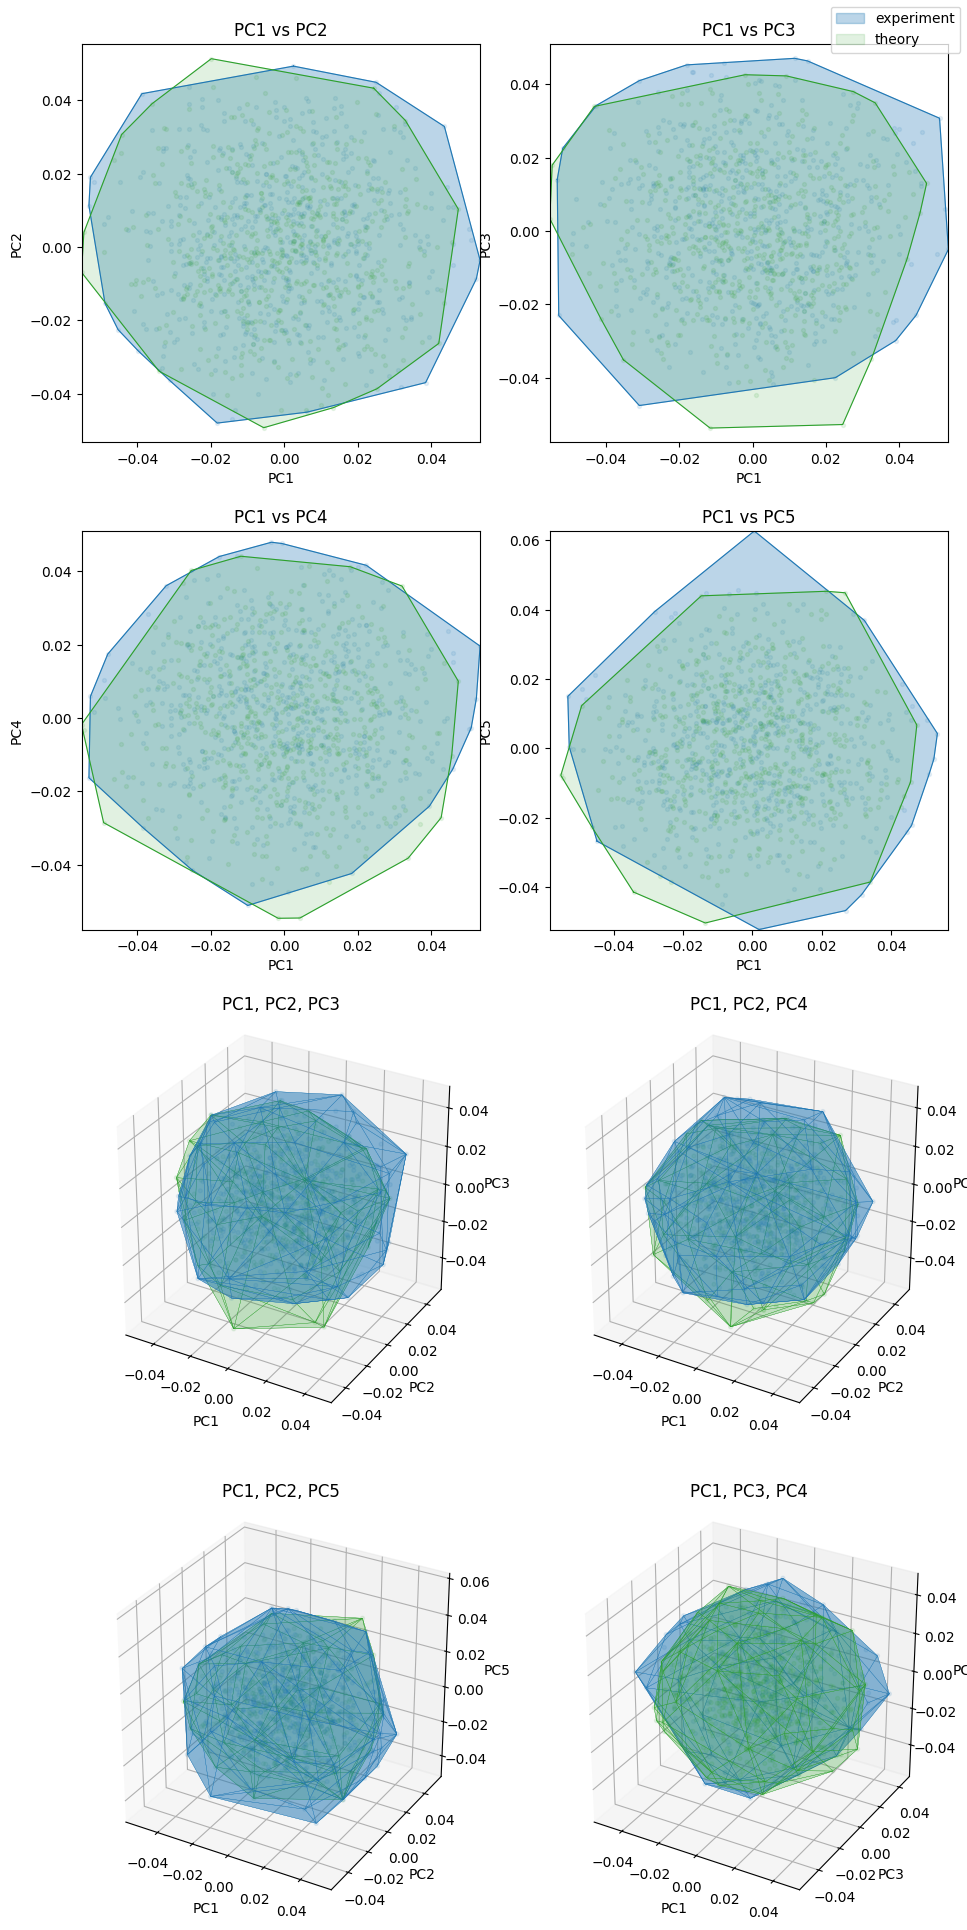

In [19]:
%matplotlib inline

plot_projection_snapshots(
    valid_p,
    valid_p_exact,
    max_points_per_set=PROJECTION_CONFIG['plot_max_points_per_set'],
    max_2d=PROJECTION_CONFIG['max_2d'],
    max_3d=PROJECTION_CONFIG['max_3d'],
    colors=('C0', 'C2'),
    labels=('experiment', 'theory'),
    alphas=(0.30, 0.14),
    filename="triples_d%d.pdf" % d,
)